# LV8 - umjetne neuronske mreže

- neuron = struktura s n ulaznih veličina x i izlaznom veličinom a
- aktivacija neurona = množenje ulaznih veličina x s težinama w i dodavanje vrijednosti pomaka b, te primjena aktivacijske funkcije g kako bi se dobila izlazna veličina a
- postoji više aktivacijskih funkcija - relu, leaky relu, sigmoid, softmax...
- neuroni se povezuju u neuronsku mrežu
- u ovoj vježbi radit ćemo jednu od osnovnih tipova mreža: unaprijedna višeslojna neuronska mreža (feedforward multilayer neural network)
    - u njoj se propagacija signala u mreži odvija isključivo od ulaza prema izlazu bez povratnih veza
- ako je svaki neuron sloja povezan sa svim neuronima prethodnog sloja, takva mreža naziva se potpuno povezana neuronska mreža (fully connected)
- ako mreža ima više od jednog skrivenog sloja, naziva se dubokom neuronskom mrežom (deep neural network)
- za izgradnju neuronskih mreža u pythonu koristit ćemo biblioteku keras i njezin layers api

In [1]:
import keras
from keras import layers

2026-04-26 13:18:10.074327: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Izgradnja potpuno povezane neuronske mreže za klasifikaciju
- neuronske mreže mogu se koristiti i za klasifikacijske probleme
- ulazni sloj mreže:
    - posebni Input sloj s parametrom shape
    - parametar shape je zapravo broj značajki u X
    - ako su nam ulazni podaci slike, onda navodimo rezoluciju slike
    - nije potrebno navoditi broj redaka u X
- izlazni sloj mreže:
    - običan Dense sloj (potpuno povezani sloj)
    - višeklasna klasifikacija - broj izlaznih neurona mora biti jednak broju klasa K i koristimo softmax aktivacijsku funkciju
    - binarna klasifikacija - jedan izlazni neuron i koristimo sigmoid aktivacijsku funkciju
    - regresija - jedan izlazni neuron, bez aktivacijske funkcije

In [10]:
model = keras.Sequential()
model.add(layers.Input(shape=(9,)))
model.add(layers.Dense(12, activation='relu'))
model.add(layers.Dense(3, activation='softmax'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 12)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            39 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 159 (636.00 B)

 Trainable params: 159 (636.00 B)

 Non-trainable params: 0 (0.00 B)

- idući korak je podešavanje modela za proces učenja metodom compile()
- za ovu metodu trebamo navesti tri parametra: loss, optimizer i metrics
- za problem višeklasne klasifikacije koristit ćemo loss='categorical_crossentropy'
- za binarnu klasifikaciju koristit ćemo loss='binary_crossentropy'
- za regresiju koristimo loss='mse'
- optimizer će nam generalno biti adam, a metrika accuracy za klasifikaciju, ili mae za regresiju

In [11]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

- naposlijetku, možemo pokrenuti učenje mreže metodom fit()
- njezini su parametri:
    - broj epoha (epochs) - ovisno o problemu može biti od nekoliko desetaka do nekoliko stotina
    - veličina minibatcha (batch_size)
    - veličina validacijskog skupa (validation_split) - nije nužno, uglavnom stavljamo 0.1

In [12]:
import pandas as pd

data = pd.read_csv('penguins.csv')

data.dropna(axis=0, inplace=True)
data = pd.get_dummies(data, columns=['island', 'sex', 'species'])

X = data.drop(columns=['species_Adelie', 'species_Gentoo', 'species_Chinstrap'])
y = data[['species_Adelie', 'species_Gentoo', 'species_Chinstrap']]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']] = scaler.fit_transform(X_train[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']])
X_test[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']] = scaler.transform(X_test[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']])

In [13]:
model.fit(X_train, y_train, epochs=100, batch_size=5, validation_split=0.1)

Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1967 - loss: 1.1306 - val_accuracy: 0.4074 - val_loss: 1.0080
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6234 - loss: 0.9125 - val_accuracy: 0.6296 - val_loss: 0.8385
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8243 - loss: 0.7446 - val_accuracy: 0.7407 - val_loss: 0.6899
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8745 - loss: 0.6021 - val_accuracy: 0.8889 - val_loss: 0.5475
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9247 - loss: 0.4769 - val_accuracy: 0.8889 - val_loss: 0.4211
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9331 - loss: 0.3747 - val_accuracy: 0.8889 - val_loss: 0.3266
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9582 - loss: 0.2955 - val_accuracy: 0.9630 - val_loss: 0.2529
Epoch 8/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9791 - loss: 0.2366 - val_accuracy: 1.0000 - v

- nakon provedenog procesa učenja, možemo evaluirati model na testnom skupu

In [15]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print('Gubitak: ', loss)
print('Tocnost: ', accuracy)

Gubitak:  0.006286210380494595
Tocnost:  1.0


- također možemo izvršiti predikciju mreže na testnom skupu:

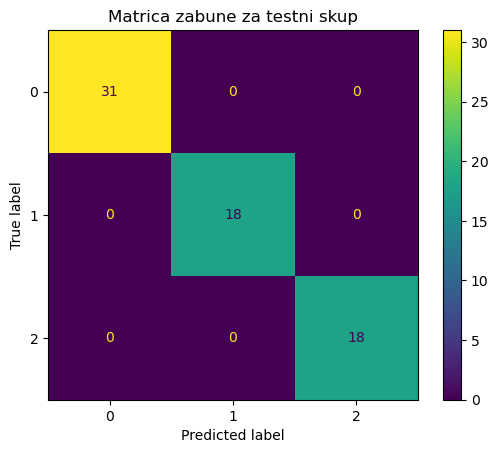

In [22]:
y_test_pred = model.predict(X_test, verbose=0)

# pošto je nama y tri odvojena enkodirana stupca, moramo ga prvo "skupiti natrag" u vrijednosti 0, 1, 2
import numpy as np
y_pred_classes = np.argmax(y_test_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test_classes, y_pred_classes), display_labels=[0, 1, 2]).plot()
plt.title('Matrica zabune za testni skup')
plt.show()